In [1]:
# Cell 1 - Imports
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from network_idx.eda.correlations import fetch_data_from_bq

In [2]:
# Cell 2 - Fetch and prepare data
tract_df = fetch_data_from_bq()

tract_df_modified = tract_df.copy()
techs = ['copper','cable','fiber']
for tech in techs:
    tract_df_modified[f'{tech}_equal_more_than_100_20_units'] = tract_df_modified[f"{tech}_speed_100_20_only"].add(tract_df_modified[f"{tech}_speed_more_than_100_20"], fill_value=0)

# tract_df_modified['perc_growth_parcels'] = round(tract_df_modified['growth_parcels'] / tract_df_modified['total_parcels'], 2)

cols_to_drop = [
    'estimated_fcc_units',
    'copper_speed_less_than_100_20',
    'copper_speed_100_20_only',
    'copper_speed_more_than_100_20',
    'cable_speed_less_than_100_20',
    'cable_speed_100_20_only',
    'cable_speed_more_than_100_20',
    'fiber_speed_less_than_100_20',
    'fiber_speed_100_20_only',
    'fiber_speed_more_than_100_20',
    'fiber_speed_equal_greater_than_100_20',
    'copper_max_upload_speed',
    'cable_max_upload_speed',
    'fiber_max_upload_speed',
    'total_parcels',
    'growth_parcels',
    'unique_locations',
    'total_flags',
    'flags_minus_greatest',
    'new_clip_count',
    'parcel_split_count',
    'mean_dist_nearest_hotspot_m',
    'mean_dist_nearest_fiber_m'
    ]

tract_df_modified = tract_df_modified.drop(columns=cols_to_drop)
print(f"Data shape after dropping columns: {tract_df_modified.shape}")

Error: Credentials file not found


/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Data shape after dropping columns: (85481, 22)


In [3]:
# Create binary indicators for growth features using percentile thresholds
binary_features_p90 = [
    'pre_early_dev_parcels',
    'landuse_change_count',
    'builder_developer_count',
    'building_permit_count'
    ]

# P90 threshold for landuse, builder, permits
for col in binary_features_p90:
    threshold = tract_df_modified[col].quantile(0.90)
    tract_df_modified[f'{col}_bin'] = (tract_df_modified[col] >= threshold).astype(int)
    print(f"{col}: P90 threshold = {threshold}, bin=1 count = {tract_df_modified[f'{col}_bin'].sum()}")

# Two versions for pre_early_dev_parcels: P75 and P90
#p75_thresh = tract_df_modified['pre_early_dev_parcels'].quantile(0.75)
#p90_thresh = tract_df_modified['pre_early_dev_parcels'].quantile(0.90)
#tract_df_modified['pre_early_dev_parcels_bin_p75'] = (tract_df_modified['pre_early_dev_parcels'] >= p75_thresh).astype(int)
#tract_df_modified['pre_early_dev_parcels_bin_p90'] = (tract_df_modified['pre_early_dev_parcels'] >= p90_thresh).astype(int)
#print(f"pre_early_dev_parcels: P75 threshold = {p75_thresh}, bin=1 count = {tract_df_modified['pre_early_dev_parcels_bin_p75'].sum()}")
#print(f"pre_early_dev_parcels: P90 threshold = {p90_thresh}, bin=1 count = {tract_df_modified['pre_early_dev_parcels_bin_p90'].sum()}")

# Drop raw count columns (replaced by binary)
tract_df_modified = tract_df_modified.drop(columns=['pre_early_dev_parcels'] + binary_features_p90)


# Keep only numeric columns for PCA
non_numeric = ['tract_geoid']
feature_cols = [c for c in tract_df_modified.select_dtypes(include='number').columns if c not in non_numeric]
df_features = tract_df_modified[feature_cols].dropna()

print(f"Features for PCA: {len(feature_cols)} columns, {len(df_features)} rows")
print(feature_cols)
print(df_features.info())

pre_early_dev_parcels: P90 threshold = 43.0, bin=1 count = 8591
landuse_change_count: P90 threshold = 8.0, bin=1 count = 8533
builder_developer_count: P90 threshold = 9.0, bin=1 count = 8708
building_permit_count: P90 threshold = 7.0, bin=1 count = 8724
Features for PCA: 21 columns, 50047 rows
['pop_ch_1yr', 'pop_pctch_1yr', 'estimated_census_housing_units', 'cable_location_count', 'cable_provider_count', 'cable_max_download_speed', 'copper_location_count', 'copper_provider_count', 'copper_max_download_speed', 'fiber_location_count', 'fiber_provider_count', 'fiber_max_download_speed', 'median_dist_nearest_hotspot', 'median_dist_nearest_fiber_m', 'copper_equal_more_than_100_20_units', 'cable_equal_more_than_100_20_units', 'fiber_equal_more_than_100_20_units', 'pre_early_dev_parcels_bin', 'landuse_change_count_bin', 'builder_developer_count_bin', 'building_permit_count_bin']
<class 'pandas.DataFrame'>
Index: 50047 entries, 0 to 85477
Data columns (total 21 columns):
 #   Column          

In [4]:
# Cell 3 - Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

k=2: inertia=949044, silhouette=0.2350
k=3: inertia=888399, silhouette=0.2032
k=4: inertia=840996, silhouette=0.1323
k=5: inertia=802804, silhouette=0.0815
k=6: inertia=767422, silhouette=0.0866
k=7: inertia=740623, silhouette=0.0845
k=8: inertia=716467, silhouette=0.0700
k=9: inertia=694646, silhouette=0.0761
k=10: inertia=678695, silhouette=0.0708
k=11: inertia=663383, silhouette=0.0725


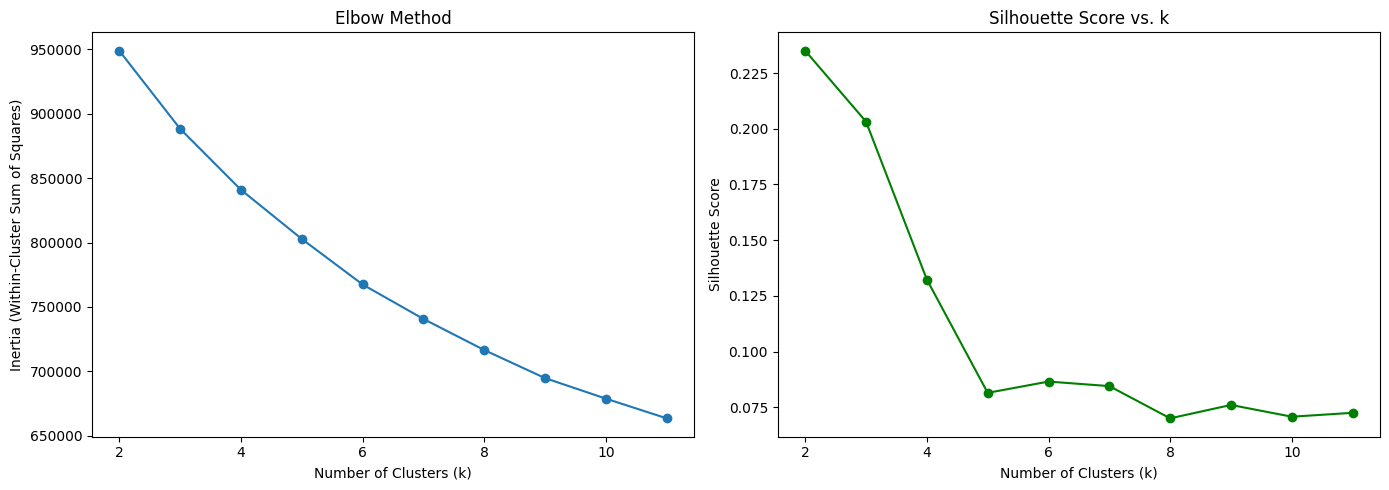

In [5]:
# Cell 4 - Elbow method + Silhouette scores to determine optimal k
K_range = range(2, 12)
inertias = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k}: inertia={km.inertia_:.0f}, silhouette={silhouette_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method')

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, marker='o', color='green')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs. k')

plt.tight_layout()

In [6]:
# Cell 5 - Fit final k-means (choose k based on above plots)
k_optimal = 6 
km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

df_features_clustered = df_features.copy()
df_features_clustered['cluster'] = cluster_labels

print(f"Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Cluster distribution:
0     1935
1     4708
2     5049
3    20089
4     4661
5    13605
Name: count, dtype: int64


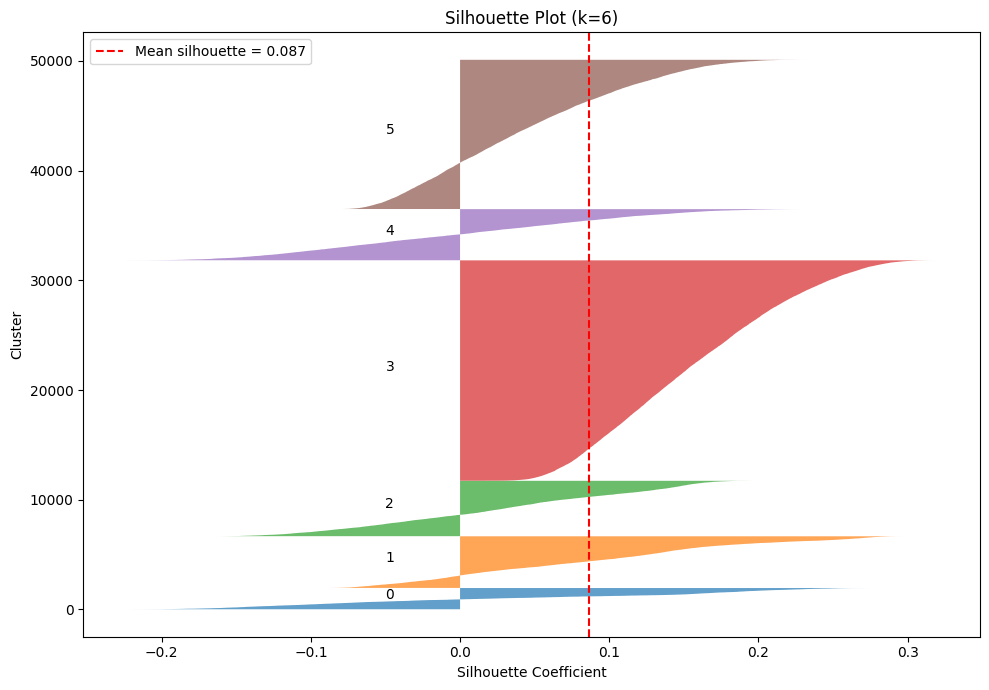

In [7]:
# Cell 6 - Silhouette analysis for chosen k
fig, ax = plt.subplots(figsize=(10, 7))
sil_values = silhouette_samples(X_scaled, cluster_labels)
y_lower = 10

for i in range(k_optimal):
    cluster_sil = np.sort(sil_values[cluster_labels == i])
    size_i = cluster_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(silhouette_score(X_scaled, cluster_labels), color='red', linestyle='--',
           label=f'Mean silhouette = {silhouette_score(X_scaled, cluster_labels):.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot (k={k_optimal})')
ax.legend()
plt.tight_layout()

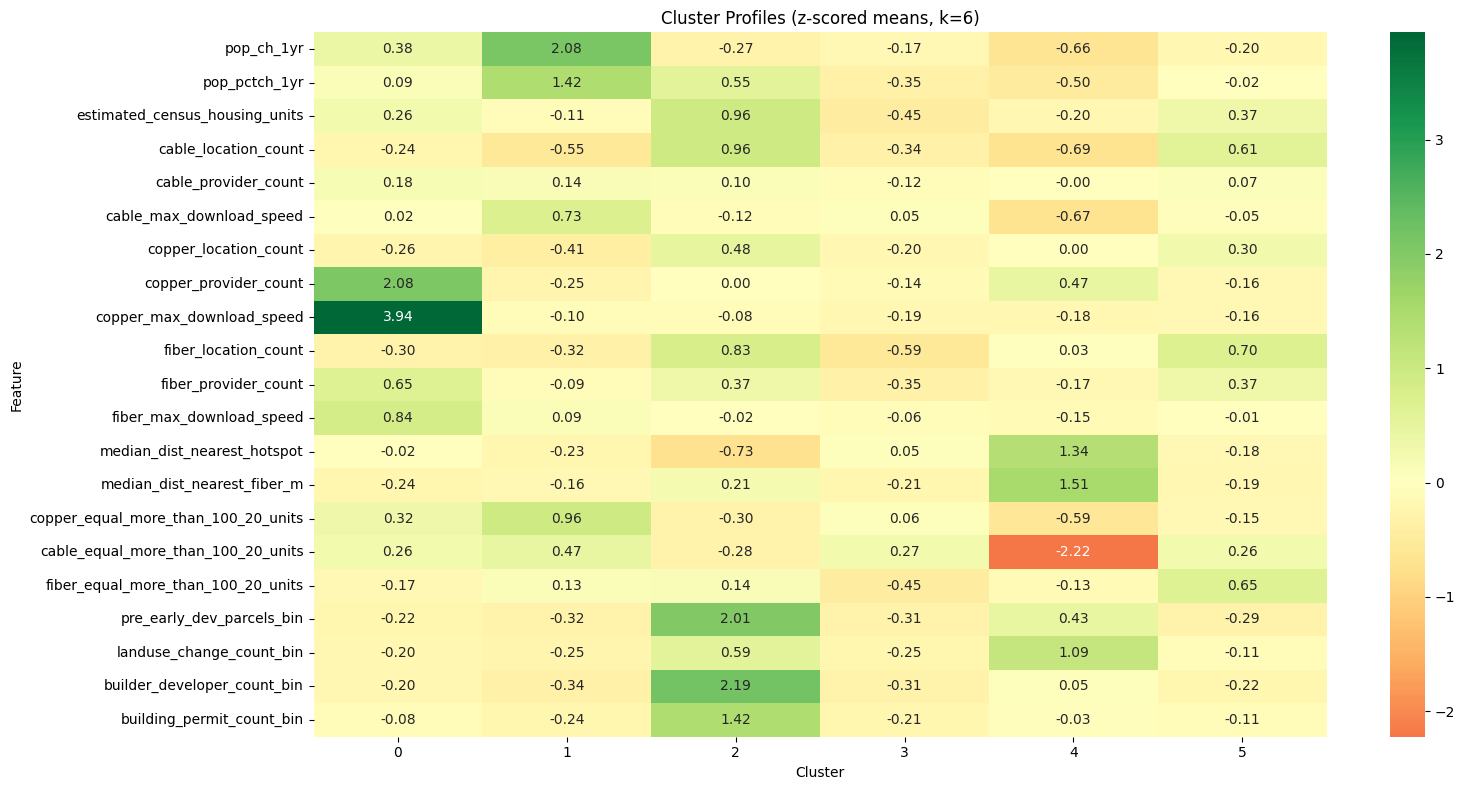

In [8]:
# Cell 7 - Cluster profiles: mean feature values per cluster
cluster_profiles = df_features_clustered.groupby('cluster')[feature_cols].mean()

# Standardized profiles for comparison (z-scores of cluster means)
cluster_profiles_z = (cluster_profiles - df_features[feature_cols].mean()) / df_features[feature_cols].std()

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(cluster_profiles_z.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title(f'Cluster Profiles (z-scored means, k={k_optimal})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()

In [9]:
# Cell 8 - Attach cluster labels back to full dataframe for downstream classification
tract_df_final = tract_df_modified.loc[df_features.index].copy()
tract_df_final['cluster'] = cluster_labels
print(f"Final dataframe shape: {tract_df_final.shape}")
tract_df_final[['tract_geoid', 'cluster']].head(10)

Final dataframe shape: (50047, 23)


,tract_geoid,cluster
0,16029960100,4
7,06019005515,4
9,13105000100,4
10,12073001602,5
12,08069002505,2
16,06019004303,0
17,01101005604,4
18,06019002905,3
19,06037700101,0
20,17073030202,4


In [10]:
# Cell 9 - Cluster distribution by state
# Extract state from tract_geoid (first 2 digits = state FIPS)
tract_df_final['state_fips'] = tract_df_final['tract_geoid'].astype(str).str.zfill(11).str[:2]

# State FIPS to abbreviation mapping
fips_to_state = {
    '01':'AL','02':'AK','04':'AZ','05':'AR','06':'CA','08':'CO','09':'CT','10':'DE',
    '11':'DC','12':'FL','13':'GA','15':'HI','16':'ID','17':'IL','18':'IN','19':'IA',
    '20':'KS','21':'KY','22':'LA','23':'ME','24':'MD','25':'MA','26':'MI','27':'MN',
    '28':'MS','29':'MO','30':'MT','31':'NE','32':'NV','33':'NH','34':'NJ','35':'NM',
    '36':'NY','37':'NC','38':'ND','39':'OH','40':'OK','41':'OR','42':'PA','44':'RI',
    '45':'SC','46':'SD','47':'TN','48':'TX','49':'UT','50':'VT','51':'VA','53':'WA',
    '54':'WV','55':'WI','56':'WY','72':'PR'
}
tract_df_final['state_abbr'] = tract_df_final['state_fips'].map(fips_to_state)

# Compute cluster percentages by state
state_cluster = tract_df_final.groupby('state_abbr')['cluster'].value_counts(normalize=True).unstack(fill_value=0)
state_cluster.columns = [f'perc_in_cluster_{c}' for c in state_cluster.columns]
state_cluster = (state_cluster * 100).round(1)

# Add total tract count per state
state_cluster.insert(0, 'total_tracts', tract_df_final.groupby('state_abbr')['cluster'].count())

state_cluster = state_cluster.sort_values('total_tracts', ascending=False)
print(state_cluster.to_string())

            total_tracts  perc_in_cluster_0  perc_in_cluster_1  perc_in_cluster_2  perc_in_cluster_3  perc_in_cluster_4  perc_in_cluster_5
state_abbr                                                                                                                                
CA                  7616               12.7                7.7                2.8               63.9                2.9               10.1
TX                  5507                6.2               18.7               14.7               21.8                8.9               29.7
FL                  3903                0.7               36.8               16.5               15.0                4.2               26.8
OH                  2496                0.6                0.1                4.5               51.6               10.7               32.4
NC                  2349                0.5                5.4               24.2               22.3               15.6               32.0
IL                  2298   

In [11]:
# Cell 10 - Upload tract_df_final to BQ (teu_analytics dataset)
from google.cloud import bigquery
from network_idx.config import GCS_PROJECT_ID, NETWORK_IDX_ENV, GCS_ADC_JSON_PATH_EP_LOCAL
from network_idx.utils import check_and_authenticate

if NETWORK_IDX_ENV == "local":
    check_and_authenticate(GCS_ADC_JSON_PATH_EP_LOCAL)

client = bigquery.Client(project=GCS_PROJECT_ID)

table_id = f"{GCS_PROJECT_ID}.teu_analytics.kmeans_clusters_tract"

# Drop helper columns not needed in BQ
upload_df = tract_df_final

job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,  # Replace table each run
)

job = client.load_table_from_dataframe(upload_df, table_id, job_config=job_config)
job.result()  # Wait for completion

print(f"Uploaded {job.output_rows} rows to {table_id}")

Error: Credentials file not found


/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Uploaded 50047 rows to clgx-gis-app-dev-06e3.teu_analytics.kmeans_clusters_tract
